In [2]:
import pickle 
import os
from pathlib import Path
from scipy import stats
import numpy as np
import datetime
import numpy as np
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import matplotlib.pyplot as plt


### **Read dict(commodity_name:df) pickle file and stats file**

In [3]:
%pwd

'c:\\Users\\BudgetGamer\\Projects\\Ian\\CommodityProject\\SystemicRiskCopulaProject\\DataFiting'

In [4]:
current_path = Path.cwd()
try:
    project_root = next(p for p in current_path.parents if p.name == "CommodityProject")
except StopIteration:
    print(Path.cwd())
except e as exception:
    print(e)

In [5]:
%cd $project_root

c:\Users\BudgetGamer\Projects\Ian\CommodityProject


In [6]:
#'rb' (write binary) mode and dump the dict into it
with open("SystemicRiskCopulaProject/Data/dfs.pkl", "rb") as f:
    dfs = pickle.load(f)

#### Checking data in dfs

In [7]:
import SystemicRiskCopulaProject.Scripts.BasicOperations as basic
import pandas as pd

In [8]:
basic.plot_commodity_analysis(dfs)

#### Read the stats

In [9]:
CommodityStats = pd.read_excel(r"SystemicRiskCopulaProject/Data/commodity_statistics_final.xlsx")

### Data fitting

I'll start normal distribution, then move on to more sophisticated non-standard gaussian distributions such as Johnsons Su, Cauchys, Student-t/Skewed-t, Pearson, Negative-Inverse Gaussian ,etc

In [10]:
ngStat = CommodityStats[CommodityStats['Commodity'] == 'NG']

In [11]:
ng_df = dfs.get("NG")
ng_df = ng_df[1:]

In [12]:
ng_16 = ng_df[ng_df['Date'] < pd.to_datetime(datetime.date(2017,1,1))]

#### Normal distribution

In [13]:
mu_mle, sigma_mle = stats.norm.fit(
    ng_16['Log_Returns'], 
    loc=np.mean(ng_16['Log_Returns']), # optional: anchor location to mean
    scale=np.std(ng_16['Log_Returns']) # optional: anchor scale to standard deviation
)

In [14]:
mu_mle, sigma_mle

(np.float64(0.0012906485414547891), np.float64(0.02516082376836086))

#### Johnsons Su 

In [15]:
# Calculate starting hints for the optimizer
mean_guess = np.mean(ng_16['Log_Returns'])
std_guess = np.std(ng_16['Log_Returns'])

# Fit with NO hard restrictions on loc and scale
a_mle, b_mle, loc_mle, scale_mle = stats.johnsonsu.fit(
    ng_16['Log_Returns'], 
    fa=0.0,            # Keeps 'a' locked at 0 if you are strictly forcing symmetry
    loc=mean_guess,    # HINT for starting location (optimizer can change it)
    scale=std_guess    # HINT for starting scale (optimizer can change it)
)

print(f"Success! Fits found:\na: {a_mle}\nb: {b_mle}\nloc: {loc_mle}\nscale: {scale_mle}")


mle_mean, mle_var, mle_skew, mle_kurt = stats.johnsonsu.stats(
    a_mle, b_mle, loc=loc_mle, scale=scale_mle, moments='mvsk'
)

print(f"MLE Fitted -> Mean: {mle_mean:.5f}, Skew: {mle_skew:.3f}, Kurt: {mle_kurt + 3:.3f}")



Success! Fits found:
a: 0.0
b: 0.0713027174190976
loc: 4.044834367712349e-11
scale: 1.5679493103744007e-10
MLE Fitted -> Mean: 0.00000, Skew: -0.000, Kurt: inf


c:\Users\BudgetGamer\Projects\Ian\CommodityProject\SystemicRiskCopulaProject\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:5978: RuntimeWarning: overflow encountered in power
  t4 = -3 + 3*expbn2**2 + 2*expbn2**3 + expbn2**4


In [16]:
def plot_modelfitness(df, a_mle, b_mle, loc_mle, scale_mle, title = 'Daily Return Distribution & Fitted Models'):
    # 1. Grid of evaluation points
    returns = df
    x = np.linspace(returns.min(), returns.max(), 500)

    # 2. Evaluate fitted PDF
    pdf_mle = stats.johnsonsu.pdf(x, a_mle, b_mle, loc=loc_mle, scale=scale_mle)

    # 3. Construct Plotly Figure
    fig = go.Figure()

    # Empirical Data Histogram
    fig.add_trace(
        go.Histogram(
            x=returns,
            histnorm='probability density',
            nbinsx=60,
            name='Empirical Data',
            marker_color='gray',
            opacity=0.5
        )
    )

    # Johnson SU PDF Curve
    fig.add_trace(
        go.Scatter(
            x=x,
            y=pdf_mle,
            mode='lines',
            name='Johnson SU (MLE)',
            line=dict(color='firebrick', width=2.5)
        )
    )

    # Layout Configuration
    fig.update_layout(
        title=title,
        xaxis_title='Daily Return',
        yaxis_title='Density',
        template='plotly_white',
        hovermode='x unified',
        width=900,
        height=500,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )

    fig.show()

In [17]:
plot_modelfitness(ng_16['Percentage_Returns'],a_mle, b_mle, loc_mle, scale_mle )


In [18]:
# Optional: If you have a massive spike of literal 0.0 values, 
# uncomment the line below to fit only active trading days:
active_returns = ng_16['Log_Returns'][ng_16['Log_Returns'] != 0]
active_returns = ng_16['Log_Returns']

# Calculate dynamic starting hints for the optimization engine
mean_guess = np.mean(active_returns)
std_guess = np.std(active_returns)

# REMOVE fa=0.0 entirely to let the Johnson SU capture market asymmetry
a_mle, b_mle, loc_mle, scale_mle = stats.johnsonsu.fit(
    active_returns, 
    loc=mean_guess,   # Starting point guess
    scale=std_guess   # Starting point guess
)

print(f"Refined Parameters:\na: {a_mle:.4f}\nb: {b_mle:.4f}\nloc: {loc_mle:.4f}\nscale: {scale_mle:.4f}")

plot_modelfitness(active_returns,a_mle, b_mle, loc_mle, scale_mle )


Refined Parameters:
a: -0.3087
b: 0.1029
loc: 0.0000
scale: 0.0000


In [19]:
# Tetsingv other returns

ng_16.columns

Index(['Date', 'Close', 'Volume', 'Percentage_Returns', 'Relative_change',
       'Log_Returns'],
      dtype='str')

In [20]:
# Calculate starting hints for the optimizer
mean_guess = np.mean(ng_16['Percentage_Returns'])
std_guess = np.std(ng_16['Percentage_Returns'])
returns = ng_16['Log_Returns']
# Fit with NO hard restrictions on loc and scale
a_mle, b_mle, loc_mle, scale_mle = stats.johnsonsu.fit(
    ng_16['Percentage_Returns'], 
    fa=0.0,            # Keeps 'a' locked at 0 if you are strictly forcing symmetry
    loc=mean_guess,    # HINT for starting location (optimizer can change it)
    scale=std_guess    # HINT for starting scale (optimizer can change it)
)

print(f"Success! Fits found:\na: {a_mle}\nb: {b_mle}\nloc: {loc_mle}\nscale: {scale_mle}")


mle_mean, mle_var, mle_skew, mle_kurt = stats.johnsonsu.stats(
    a_mle, b_mle, loc=loc_mle, scale=scale_mle, moments='mvsk'
)

print(f"MLE Fitted -> Mean: {mle_mean:.5f}, Skew: {mle_skew:.3f}, Kurt: {mle_kurt + 3:.3f}")



Success! Fits found:
a: 0.0
b: 0.13774715458904663
loc: 5.839264349639227e-14
scale: 2.3772207523020823e-12
MLE Fitted -> Mean: 0.00000, Skew: -0.000, Kurt: 17919657181952354181489068934513197697378492606023608081631167482637672228256750371914907648.000


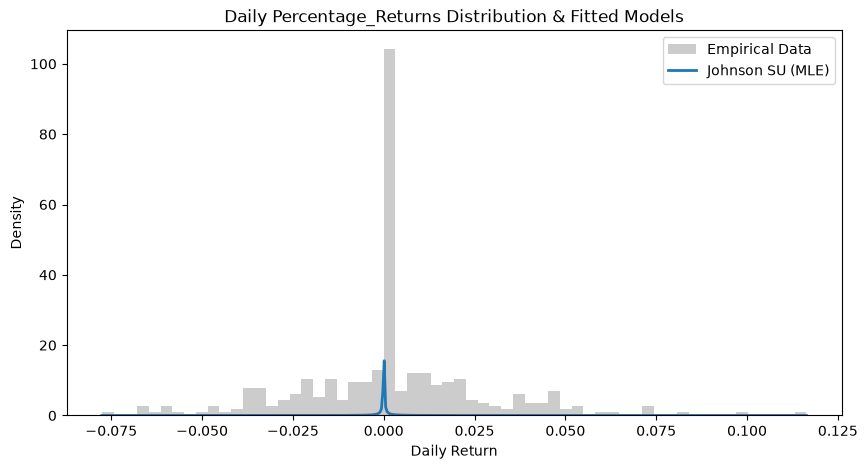

In [21]:
x = np.linspace(returns.min(), returns.max(), 500)

# Evaluate fitted PDFs
pdf_mle = stats.johnsonsu.pdf(x, a_mle, b_mle, loc=loc_mle, scale=scale_mle)

plt.figure(figsize=(10, 5))
plt.hist(returns, bins=60, density=True, alpha=0.4, color='gray', label='Empirical Data')
plt.plot(x, pdf_mle, label='Johnson SU (MLE)', linewidth=2)
plt.title('Daily Percentage_Returns Distribution & Fitted Models')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.show()


plot_modelfitness(ng_16['Percentage_Returns'],a_mle, b_mle, loc_mle, scale_mle )


In [22]:
# Calculate starting hints for the optimizer
mean_guess = np.mean(ng_16['Relative_change'])
std_guess = np.std(ng_16['Relative_change'])

# Fit with NO hard restrictions on loc and scale
a_mle, b_mle, loc_mle, scale_mle = stats.johnsonsu.fit(
    ng_16['Relative_change'], 
    fa=0.0,            # Keeps 'a' locked at 0 if you are strictly forcing symmetry
    loc=mean_guess,    # HINT for starting location (optimizer can change it)
    scale=std_guess    # HINT for starting scale (optimizer can change it)
)

print(f"Success! Fits found:\na: {a_mle}\nb: {b_mle}\nloc: {loc_mle}\nscale: {scale_mle}")


mle_mean, mle_var, mle_skew, mle_kurt = stats.johnsonsu.stats(
    a_mle, b_mle, loc=loc_mle, scale=scale_mle, moments='mvsk'
)

print(f"MLE Fitted -> Mean: {mle_mean:.5f}, Skew: {mle_skew:.3f}, Kurt: {mle_kurt + 3:.3f}")

Success! Fits found:
a: 0.0
b: 0.054831819302473314
loc: 4.573134241939844e-16
scale: 2.835941456600178e-16
MLE Fitted -> Mean: 0.00000, Skew: -0.000, Kurt: inf


c:\Users\BudgetGamer\Projects\Ian\CommodityProject\SystemicRiskCopulaProject\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:5976: RuntimeWarning: overflow encountered in multiply
  t2 = 4*expbn2**2 * (expbn2 + 2) * np.cosh(2*a_b)


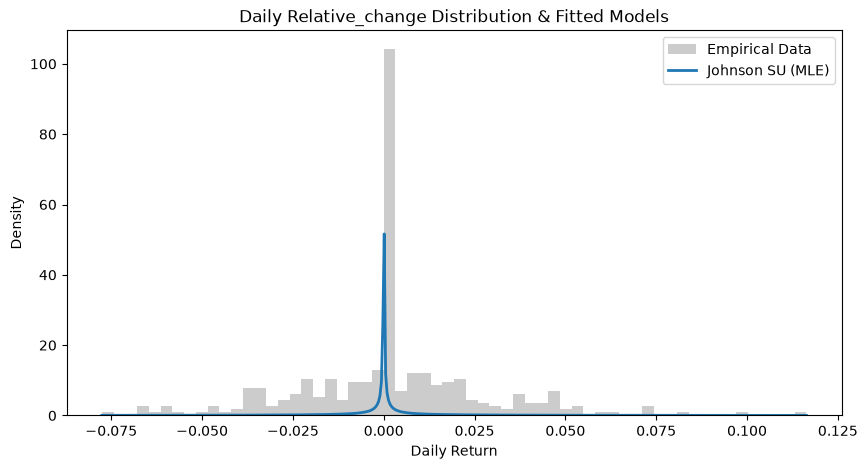

In [23]:
x = np.linspace(returns.min(), returns.max(), 500)

# Evaluate fitted PDFs
pdf_mle = stats.johnsonsu.pdf(x, a_mle, b_mle, loc=loc_mle, scale=scale_mle)

plt.figure(figsize=(10, 5))
plt.hist(returns, bins=60, density=True, alpha=0.4, color='gray', label='Empirical Data')
plt.plot(x, pdf_mle, label='Johnson SU (MLE)', linewidth=2)
plt.title('Daily Relative_change Distribution & Fitted Models')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.show()


plot_modelfitness(ng_16['Relative_change'],a_mle, b_mle, loc_mle, scale_mle )


#### Standardize or normalize

In [24]:
# Calculate empirical sample metrics
mu_raw = np.mean(ng_16['Log_Returns'])
std_raw = np.std(ng_16['Log_Returns'])

# Standardize inputs
data_std = (ng_16['Log_Returns'] - mu_raw) / std_raw

# Fit standard Johnson SU
a_std, b_std, loc_std, scale_std = stats.johnsonsu.fit(data_std)


In [25]:
# Calculate empirical moments
mu_emp = np.mean(ng_16['Log_Returns'])
sigma_emp = np.std(ng_16['Log_Returns'], ddof=1)

# Standardize returns
z_returns = (ng_16['Log_Returns'] - mu_emp) / sigma_emp

# Compute sample skewness and excess kurtosis
skew_emp = stats.skew(z_returns)
kurt_emp = stats.kurtosis(z_returns)  # excess kurtosis

# Provide heuristic initial guesses
# Higher kurtosis implies smaller shape parameter 'b' (heavier tails)
b_init = np.sqrt(2.0 / np.maximum(kurt_emp, 0.1))
a_init = -skew_emp * b_init / 2.0


In [26]:
a_std, b_std, loc_std, scale_std = stats.johnsonsu.fit(
    z_returns,
    a_init,      # initial guess for shape parameter 'a'
    b_init,      # initial guess for shape parameter 'b'
    loc=0.0,     # initial guess for location
    scale=1.0    # initial guess for scale
)

#### Rescale back to Raw return space:

Under a linear transformation $X = \mu + \sigma Z$: <br>
Shape parameters $a$ and $b$ are scale- and location-invariant ($a_{\text{raw}} = a_{\text{std}}$, $b_{\text{raw}} = b_{\text{std}}$).<br>
Location and scale transform according to:<br>
* $\text{scale}_{\text{raw}} = \text{scale}_{\text{std}} \cdot \sigma_{\text{emp}}$
* $\text{loc}_{\text{raw}} = \text{loc}_{\text{std}} \cdot \sigma_{\text{emp}} + \mu_{\text{emp}}$

In [27]:
a_raw, b_raw = a_std, b_std
scale_raw = scale_std*sigma_emp
loc_raw = loc_std*sigma_emp+mu_emp

print(f'Raw parameters \n a_raw :{a_raw} b_raw: {b_raw} scale_raw:{scale_raw} loc_raw:{loc_raw} \n \nScaled parameters:\n scale_std : {scale_std} loc_std : {loc_std}')

Raw parameters 
 a_raw :-0.08082648461640493 b_raw: 0.061747162764471925 scale_raw:4.3467395678319725e-14 loc_raw:5.272540216927357e-14 
 
Scaled parameters:
 scale_std : 1.7251945611416996e-12 loc_std : -0.05122505752243356


In [28]:
plot_modelfitness(ng_16['Log_Returns'],a_raw, b_raw,loc_raw, scale_raw , title = 'NG Daily Log standardized return distribution')

Step 4: Extract Uniform Marginals for the Copula (PIT)In copula modeling, the primary goal of marginal fitting is Probability Integral Transform (PIT) to map returns onto $U(0, 1)$:$$U_i = F_{\text{JSU}}(x_i; a, b, \text{loc}, \text{scale}) \sim U(0,1)$$

<br> <br>
**Probability Integral Transform (PIT)** <br>
u_ng = stats.johnsonsu.cdf(ng_returns, a_raw, b_raw, loc=loc_raw, scale=scale_raw)<br>

Goodness-of-fit diagnostic for marginals before copula fitting<br>
Evaluates uniform uniformity via Kolmogorov-Smirnov test<br>
ks_stat, p_val = stats.kstest(u_ng, 'uniform')

In [29]:
# Fit on z-scored returns
a_std, b_std, loc_std, scale_std = stats.johnsonsu.fit(z_returns)

# Rescale parameters to raw domain
scale_raw = scale_std * sigma_emp
loc_raw = loc_std * sigma_emp + mu_emp

# Uniform transform for copula input
u_ng = stats.johnsonsu.cdf(
    ng_16['Log_Returns'], a=a_std, b=b_std, loc=loc_raw, scale=scale_raw
)

ks_stat, p_val = stats.kstest(u_ng, "uniform")

In [ ]:
ks_stat, p_val

(np.float64(0.3484920387553575), np.float64(8.540355673907093e-40))

Its clear that p value for Kolmogorov-Smirnov test is lower than .05, so it rejects the null hypothesis 

The issue with data is that it contains a lot of zeros on weekends

In [ ]:
'''
from pathlib import Path

output_path = Path.home() / "Downloads" / "ng_16.csv"
ng_16.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")'''

Saved to: C:\Users\BudgetGamer\Downloads\ng_16.csv


### I'll do ks test w all years and no weekends

In [31]:
ng_df

,Date,Close,Volume,Percentage_Returns,Relative_change,Log_Returns
1,2016-01-05,2.325,123923.0,-0.003856,0.058,-0.003864
2,2016-01-06,2.267,166278.0,-0.024946,-0.115,-0.025263
3,2016-01-07,2.382,214462.0,0.050728,-0.090,0.049483
4,2016-01-08,2.472,163907.0,0.037783,0.000,0.037087
5,2016-01-09,2.472,163907.0,0.000000,0.000,0.000000
...,...,...,...,...,...,...
3885,2026-08-24,2.782,90855.0,0.003246,0.012,0.003240
3886,2026-08-25,2.770,42228.0,-0.004313,-0.072,-0.004323
3887,2026-08-26,2.842,68681.0,0.025993,-0.065,0.025661
3888,2026-08-27,2.907,188571.0,0.022871,0.019,0.022614


In [32]:
ng_df.dropna()

,Date,Close,Volume,Percentage_Returns,Relative_change,Log_Returns
1,2016-01-05,2.325,123923.0,-0.003856,0.058,-0.003864
2,2016-01-06,2.267,166278.0,-0.024946,-0.115,-0.025263
3,2016-01-07,2.382,214462.0,0.050728,-0.090,0.049483
4,2016-01-08,2.472,163907.0,0.037783,0.000,0.037087
5,2016-01-09,2.472,163907.0,0.000000,0.000,0.000000
...,...,...,...,...,...,...
3884,2026-08-23,2.773,110328.0,0.000000,-0.009,0.000000
3885,2026-08-24,2.782,90855.0,0.003246,0.012,0.003240
3886,2026-08-25,2.770,42228.0,-0.004313,-0.072,-0.004323
3887,2026-08-26,2.842,68681.0,0.025993,-0.065,0.025661


In [35]:
from pandas.tseries.holiday import USFederalHolidayCalendar

USholiday = USFederalHolidayCalendar()
hols = USholiday.holidays(start=ng_df['Date'].min(), end=ng_df['Date'].max())


In [36]:
ng_df_cleaned = ng_df[(ng_df['Date'].dt.weekday < 5) & ~(ng_df['Date'].isin(hols))]

In [37]:
ng_df_cleaned

,Date,Close,Volume,Percentage_Returns,Relative_change,Log_Returns
1,2016-01-05,2.325,123923.0,-0.003856,0.058,-0.003864
2,2016-01-06,2.267,166278.0,-0.024946,-0.115,-0.025263
3,2016-01-07,2.382,214462.0,0.050728,-0.090,0.049483
4,2016-01-08,2.472,163907.0,0.037783,0.000,0.037087
7,2016-01-11,2.396,146842.0,-0.030744,0.139,-0.031227
...,...,...,...,...,...,...
3885,2026-08-24,2.782,90855.0,0.003246,0.012,0.003240
3886,2026-08-25,2.770,42228.0,-0.004313,-0.072,-0.004323
3887,2026-08-26,2.842,68681.0,0.025993,-0.065,0.025661
3888,2026-08-27,2.907,188571.0,0.022871,0.019,0.022614


In [38]:
n = ng_df_cleaned[ng_df_cleaned['Log_Returns']==0]

In [50]:
n['Date']

81     2016-03-25
242    2016-09-02
466    2017-04-14
816    2018-03-30
1029   2018-10-29
1038   2018-11-07
1066   2018-12-05
1129   2019-02-06
1201   2019-04-19
1558   2020-04-10
1627   2020-06-18
1732   2020-10-01
1807   2020-12-15
1915   2021-04-02
2041   2021-08-06
2088   2021-09-22
2293   2022-04-15
2650   2023-04-07
3007   2024-03-29
3392   2025-04-18
3742   2026-04-03
Name: Date, dtype: datetime64[s]

11/21 days w 0 returns are Good-Friday : 2016‑03‑25, 2017‑04‑14, 2018‑03‑30, 2019‑04‑19, 2020‑04‑10, 2021‑04‑02, 2022‑04‑15, 2023‑04‑07, 2024‑03‑29, 2025‑04‑18, 2026‑04‑03

2018‑12‑05 : National mourning for President George HW Bush

In [62]:
_d ='2016‑03‑25'
_d = _d.replace('\x2011', '-').replace('‑', '-')
datetime.datetime.strptime(_d, "%Y-%m-%d")

datetime.datetime(2016, 3, 25, 0, 0)

In [67]:
# Remove good friday and 2018-12-05
_additionalHolidays = ['2016‑03‑25', '2017‑04‑14', '2018‑03‑30', '2019‑04‑19', '2020‑04‑10', '2021‑04‑02', '2022‑04‑15', '2023‑04‑07', '2024‑03‑29', '2025‑04‑18', '2026‑04‑03']

additionalHolidays = [ datetime.datetime.strptime(_d.replace('\x2011', '-').replace('‑', '-'), "%Y-%m-%d") for _d in _additionalHolidays]

In [71]:
ng_df_cleaned = ng_df_cleaned[~(ng_df_cleaned['Date'].isin(additionalHolidays))]

In [76]:
# Calculate empirical sample metrics
mu_raw = np.mean(ng_df_cleaned['Log_Returns'])
std_raw = np.std(ng_df_cleaned['Log_Returns'])

# Standardize inputs
data_std = (ng_df_cleaned['Log_Returns'] - mu_raw) / std_raw

# Fit standard Johnson SU
a_std, b_std, loc_std, scale_std = stats.johnsonsu.fit(data_std)

# Calculate empirical moments
mu_emp = np.mean(ng_df_cleaned['Log_Returns'])
sigma_emp = np.std(ng_df_cleaned['Log_Returns'], ddof=1)

# Standardize returns
z_returns = (ng_df_cleaned['Log_Returns'] - mu_emp) / sigma_emp

# Compute sample skewness and excess kurtosis
skew_emp = stats.skew(z_returns)
kurt_emp = stats.kurtosis(z_returns)  # excess kurtosis

# Provide heuristic initial guesses
# Higher kurtosis implies smaller shape parameter 'b' (heavier tails)
b_init = np.sqrt(2.0 / np.maximum(kurt_emp, 0.1))
a_init = -skew_emp * b_init / 2.0


In [77]:
a_std, b_std, loc_std, scale_std = stats.johnsonsu.fit(
    z_returns,
    a_init,      # initial guess for shape parameter 'a'
    b_init,      # initial guess for shape parameter 'b'
    loc=0.0,     # initial guess for location
    scale=1.0    # initial guess for scale
)

In [78]:
a_raw, b_raw = a_std, b_std
scale_raw = scale_std*sigma_emp
loc_raw = loc_std*sigma_emp+mu_emp

print(f'Raw parameters \n a_raw :{a_raw} b_raw: {b_raw} scale_raw:{scale_raw} loc_raw:{loc_raw} \n \nScaled parameters:\n scale_std : {scale_std} loc_std : {loc_std}')

Raw parameters 
 a_raw :0.021508450226785634 b_raw: 1.281348703439948 scale_raw:0.037895494643009314 loc_raw:0.0009130012084226592 
 
Scaled parameters:
 scale_std : 0.8792187245015155 loc_std : 0.02061521037852084


In [79]:
plot_modelfitness(ng_df_cleaned['Log_Returns'],a_raw, b_raw,loc_raw, scale_raw , title = 'NG Daily Log standardized return distribution')

In [84]:
# Fit on z-scored returns
a_std, b_std, loc_std, scale_std = stats.johnsonsu.fit(z_returns)

# Rescale parameters to raw domain
scale_raw = scale_std * sigma_emp
loc_raw = loc_std * sigma_emp + mu_emp

# Uniform transform for copula input
u_ng = stats.johnsonsu.cdf(
    ng_df_cleaned['Log_Returns'], a=a_std, b=b_std, loc=loc_raw, scale=scale_raw
)

ks_stat, p_val = stats.kstest(u_ng, "uniform")

In [85]:
ks_stat, p_val

(np.float64(0.010327124863273751), np.float64(0.9365273003910157))

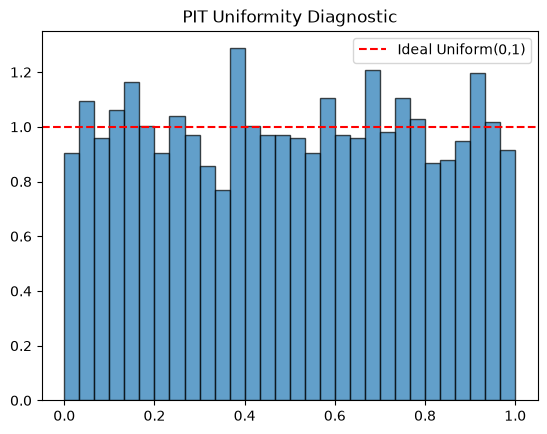

In [86]:
import matplotlib.pyplot as plt

# Correct evaluation
u_ng = stats.johnsonsu.cdf(z_returns, a=a_std, b=b_std, loc=loc_std, scale=scale_std)

# Visual check: Should be flat/uniform
plt.hist(u_ng, bins=30, density=True, edgecolor='black', alpha=0.7)
plt.axhline(1.0, color='red', linestyle='--', label='Ideal Uniform(0,1)')
plt.title("PIT Uniformity Diagnostic")
plt.legend()
plt.show()

In [87]:
u_ng

array([0.44460427, 0.21041114, 0.91754165, ..., 0.79045573, 0.76430037,
       0.40934767], shape=(2658,))